<a href="https://www.kaggle.com/code/alejoalarcon24/cyclistic-bike-share?scriptVersionId=326472489" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Case study 1: How does a bike-share navigate speedy success? Cyclistic Bike-Share Analysis

### How do annual members and casul riders use Cyclistic bikes differently?



**Author:** Luis Alejandro Alarcón Vargas  
**Date:** Junio 2026  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Data source:** [Divvy Trip Data](https://divvy-tripdata.s3.amazonaws.com/index.html)


## Business Context

Cyclistic is a fictional bike-share company based in Chicago with over 5.800 bicycles 
and 600 docking stations. The company offers three pricing plans: single-ride passes, 
full-day passes, and annual memberships.

Cyclistic's finance team has determined that **annual members are significantly more 
profitable** than casual riders. The director of marketing believes that converting 
casual riders into annual members is key to future growth.

## Business Task

Analyze how annual members and casual riders use Cyclistic bikes differently, 
in order to provide data-driven recommendations that help convert casual riders 
into annual members.

## Key Question
 *How do annual members and casual riders use Cyclistic bikes differently?*

## Table of Contents

1. [Ask — Business Task](#1-ask)
2. [Prepare — Data Sources](#2-prepare)
3. [Process — Data Cleaning](#3-process)
4. [Analyze — Exploratory Analysis](#4-analyze)
5. [Share — Visualizations & Findings](#5-share)
6. [Act — Recommendations](#6-act)

---
## 1. Ask — Business Task <a name="1-ask"></a>

### Business Task Statement

Analyze the behavioral differences between casual riders and annual members 
of Cyclistic's bike-share service, using 12 months of historical trip data, in order 
to identify actionable patterns that support a data-driven marketing strategy aimed 
at converting casual riders into annual members.

### Key Stakeholders

| Stakeholder | Role | Interest in this analysis |
|---|---|---|
| Lily Moreno | Director of Marketing | Design conversion strategies |
| Cyclistic Executive Team | Decision makers | Approve marketing programs |
| Marketing Analytics Team | Analysts | Execute data-driven campaigns |

### Guiding Questions

The analysis will focus on the following questions:

1. **How** do annual members and casual riders use Cyclistic bikes differently?
2. **Why** would casual riders buy an annual membership?
3. **How** can digital media influence casual riders to become members?

**This notebook addresses question #1 as the primary business task assigned.**

---
## 2. Prepare — Data Sources <a name="2-prepare"></a>

### Data Source Description

- **Source:** [Divvy Trip Data](https://divvy-tripdata.s3.amazonaws.com/index.html) 
  provided by Motivate International Inc.
- **License:** [Data License Agreement](https://divvybikes.com/data-license-agreement)
- **Format:** CSV files, one per month
- **Period covered:** May 01 2026 — April 30 2026 *(last month)*
- **Total files:** 12

### Data Structure

Each file contains one row per trip with the following fields:

| Column | Description |
|---|---|
| `ride_id` | Unique identifier for each trip |
| `rideable_type` | Type of bike (classic, electric, docked) |
| `started_at` | Trip start datetime |
| `ended_at` | Trip end datetime |
| `start_station_name` | Name of the departure station |
| `start_station_id` | ID of the departure station |
| `end_station_name` | Name of the arrival station |
| `end_station_id` | ID of the arrival station |
| `start_lat` / `start_lng` | Start coordinates |
| `end_lat` / `end_lng` | End coordinates |
| `member_casual` | Rider type: **member** or **casual** |

### Privacy & Limitations

- No personally identifiable information (PII) is included
- It is not possible to connect trips to individual riders
- Cannot determine if casual riders are local residents or tourists

### Data Credibility — ROCCC Assessment

| Criteria | Assessment |
|---|---|
| **Reliable** | First-party data collected directly by Divvy's tracking system |
| **Original** | Raw source data, not aggregated by a third party |
| **Comprehensive** | Covers all trips citywide for a full 12-month period |
| **Current** | Most recent 12 months available |
| **Cited** | Publicly available under official Motivate Int'l license |

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Utilities
import os
import glob
from datetime import datetime

print("Libraries loaded successfully")

Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully


In [2]:
import os
import glob

print("Current directory:", os.getcwd())
print("Files found:", glob.glob("/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/*.csv"))


Current directory: /kaggle/working
Files found: ['/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202505-divvy-tripdata.csv', '/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202604-divvy-tripdata.csv', '/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202509-divvy-tripdata.csv', '/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202511-divvy-tripdata.csv', '/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202512-divvy-tripdata.csv', '/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202506-divvy-tripdata.csv', '/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202603-divvy-tripdata.csv', '/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202507-divvy-tripdata.csv', '/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/202601-

In [3]:
# Path to raw data folder
data_path = "/kaggle/input/datasets/alejoalarcon24/cyclistic-trip-data-may-2025-to-apr-2026/*.csv"

# Load and concatenate all monthly files
all_files = glob.glob(data_path)
df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

print(f"Total files loaded: {len(all_files)}")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")


Total files loaded: 12
Total rows: 5,697,455
Total columns: 13


In [4]:
# Quick overview
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,LF-005,Winthrop Ave & Lawrence Ave,TA1308000021,41.91,-87.63,41.97,-87.66,member
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,TA1308000006,Desplaines St & Jackson Blvd,15539,41.89,-87.68,41.88,-87.64,member
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,13430,Clark St & Elm St,TA1307000039,41.89,-87.63,41.90,-87.63,member
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,13242,Damen Ave & Cortland St,13133,41.92,-87.69,41.92,-87.68,member
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,TA1305000017,Clinton St & Roosevelt Rd,WL-008,41.87,-87.65,41.87,-87.64,member


In [5]:
# Data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5697455 entries, 0 to 5697454
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 565.1+ MB


In [6]:
# Basic statistics
df.describe()

,start_lat,start_lng,end_lat,end_lng
count,5697455.00,5697455.00,5691598.00,5691598.00
mean,41.90,-87.65,41.90,-87.65
std,0.04,0.03,0.04,0.03
min,41.65,-87.89,41.49,-88.10
25%,41.88,-87.66,41.88,-87.66
50%,41.90,-87.64,41.90,-87.64
75%,41.93,-87.63,41.93,-87.63
max,42.07,-87.52,42.21,-87.42


In [7]:
# Null values per column
df.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1215745
start_station_id      1215745
end_station_name      1279863
end_station_id        1279863
start_lat                   0
start_lng                   0
end_lat                  5857
end_lng                  5857
member_casual               0
dtype: int64

As we can see, 6 of the 13 columns have null values, both start_station_name and start_station_id have 1,215,745 null values, besides, end_station_name and end_station_id presents 1,279,863 null values. In both cases we can infer that not all the bikes were started and ended in stations, it's normal cause not all the users go to stations directly; this behavior is represented specially in electric bikes.

The variables end_lat, and end_lng have 5,857 null values, with analysis you can infer that there isn't null values for start_lat and start_lng, this explain that all the data have an start point of rindig, but 5,857 rides don't have an end point of riding, probably some error or damage in the GPS, or the byke was stolen, this factors could be affected the data.

In [8]:
# proportion of null values per column
df.isnull().sum() / len(df) * 100

ride_id               0.00
rideable_type         0.00
started_at            0.00
ended_at              0.00
start_station_name   21.34
start_station_id     21.34
end_station_name     22.46
end_station_id       22.46
start_lat             0.00
start_lng             0.00
end_lat               0.10
end_lng               0.10
member_casual         0.00
dtype: float64

In [9]:
# duplicate rows
print(f"Duplicate rows: {df.duplicated().sum():,}")

Duplicate rows: 0


In [10]:
# distribution of user types
df['member_casual'].value_counts()

member_casual
member    3659658
casual    2037797
Name: count, dtype: int64

In [11]:
# bike types distribution
df['rideable_type'].value_counts()

rideable_type
electric_bike    3761130
classic_bike     1936325
Name: count, dtype: int64

In [12]:
# The null values coincide with electrical cycles?
df[df['start_station_name'].isnull()]['rideable_type'].value_counts()

rideable_type
electric_bike    1215745
Name: count, dtype: int64

Here we confirm that all the null values of the start_station_name are electric bikes, there is strong correlation between null values of start_station_name and electrycal bikes trips. This confirms that electric bike users frequently pick up and drop off bycicles outside the physical stations. This confirms a valid data quality, the null values are corresponding to flexibility way of use, and not data quality issue.

## 3. Process — Data Cleaning <a name="3-process"></a>

### Cleaning Strategy

Based on the exploratory analysis, the following issues were identified and addressed:

| Issue | Decision | Justification |
|---|---|---|
| Null station names and id (~21%) | Keep rows | Expected behavior for electric bikes picked up off-station |
| Null end coordinates (1.02%) | Keep rows | This rows contain types, datetime and duration of trips |
| Duplicate rows | No action needed | Zero duplicates found |

Note: The null end coordinates can be deleted in a potential final destination maps analysis.

In [13]:
# 1. Create ride_length in minutes
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
df['ride_length_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# 2. Remove negative or zero ride lengths (data entry errors)
df = df[df['ride_length_min'] > 0]
print(f"Rows after removing invalid ride lengths: {df.shape[0]:,}")

# 3. Remove extreme outliers (rides over 24 hours — likely unreturned bikes)
df = df[df['ride_length_min'] <= 1440]
print(f"Rows after removing outliers: {df.shape[0]:,}")

# 4. Extract time features
df['day_of_week'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month_name()
df['hour'] = df['started_at'].dt.hour

print("\nCleaning complete")

Rows after removing invalid ride lengths: 5,697,426
Rows after removing outliers: 5,691,593

Cleaning complete


The initial number of rows was 5,697,454. With the first removal we obtained 5,697,426 
rows, only 28 rows had negative or zero ride lengths. With the second removal we obtained 
5,691,593 rows, removing almost 6,000 extreme outliers representing rides over 24 hours.

Note: Rows with null station names (around 21%) were intentionally kept, as they correspond 
to electric bike trips where off-station pickup/dropoff is an expected behavior.

### Cleaning Summary

| Step | Action | Rows Removed | Rows Remaining |
|---|---|---|---|
| Initial dataset | — | — | 5,697,454 |
| Remove zero/negative ride lengths | Drop rows | 28 | 5,697,426 |
| Remove rides over 24 hours | Drop rows | 5,833 | 5,691,593 |

In [14]:
# Confirm cleaned dataset
print(f"Final dataset shape: {df.shape}")
print(f"\nRemaining nulls:")
print(df.isnull().sum())

Final dataset shape: (5691593, 17)

Remaining nulls:
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1215741
start_station_id      1215741
end_station_name      1274151
end_station_id        1274151
start_lat                   0
start_lng                   0
end_lat                   222
end_lng                   222
member_casual               0
ride_length_min             0
day_of_week                 0
month                       0
hour                        0
dtype: int64


In [15]:
print(f"\nRide length stats (minutes):")
print(df['ride_length_min'].describe())


Ride length stats (minutes):
count   5691593.00
mean         14.50
std          28.91
min           0.00
25%           5.37
50%           9.39
75%          16.49
max        1439.98
Name: ride_length_min, dtype: float64


## 4. Analyze — Exploratory Analysis <a name="4-analyze"></a>

The analysis is structured around four main parts to understand behavioral differences 
between casual riders and annual members:

1. **Ride Duration** — How long do they ride?
2. **Weekly Patterns** — Which days do they prefer?
3. **Monthly Patterns** — How does usage vary across the year?
4. **Hourly Patterns** — What time of day do they ride?

In [16]:
# Split dataset by user type
members = df[df['member_casual'] == 'member']
casuals = df[df['member_casual'] == 'casual']
print(f"Casuals:  {len(casuals):,} rides ({len(casuals)/len(df)*100:.1f}%)")

Casuals:  2,032,986 rides (35.7%)


In [17]:
# Ride length statistics by user type
ride_stats = df.groupby('member_casual')['ride_length_min'].agg([
    ('Mean (min)', 'mean'),
    ('Median (min)', 'median'),
    ('Max (min)', 'max'),
    ('Std Dev', 'std')
]).round(2)

print("=== Ride Length by User Type ===")
print(ride_stats)

=== Ride Length by User Type ===
               Mean (min)  Median (min)  Max (min)  Std Dev
member_casual                                              
casual              18.96         11.27    1439.98    38.47
member              12.02          8.58    1439.90    21.46


In [18]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly = df.groupby(['member_casual', 'day_of_week']).size().reset_index(name='ride_count')
weekly['day_of_week'] = pd.Categorical(weekly['day_of_week'], categories=day_order, ordered=True)
weekly = weekly.sort_values('day_of_week')

print("=== Rides by Day of Week ===")
print(weekly.pivot(index='day_of_week', columns='member_casual', values='ride_count'))

=== Rides by Day of Week ===
member_casual  casual  member
day_of_week                  
Monday         232384  513835
Tuesday        228824  580822
Wednesday      228971  578187
Thursday       268279  601935
Friday         319751  538639
Saturday       415506  453793
Sunday         339271  391396


### Analysis 2: Weekly Usage Patterns

| Day | Casual | Member |
|---|---|---|
| Monday | 232,384 | 513,835 |
| Tuesday | 228,824 | 580,822 |
| Wednesday | 228,971 | 578,187 |
| Thursday | 268,279 | 601,935 |
| Friday | 319,751 | 538,639 |
| Saturday | 415,506 | 453,793 |
| Sunday | 339,271 | 391,396 |

#### Key Findings

**1. Members are weekday-dominant riders**
Annual members show their highest usage from Tuesday through Thursday, peaking 
on Thursday with 601,935 rides. As the weekend approaches, their ridership 
consistently declines, dropping from 538,639 on Friday to 391,396 on Sunday. 
This pattern strongly suggests that members use Cyclistic bikes primarily as a 
commuting tool, with usage tied directly to the working week.

**2. Casual riders are weekend-dominant riders**
Casual riders show the opposite pattern. Their usage steadily increases throughout 
the week, peaking on Saturday with 415,506 rides, their single busiest day. 
Sunday maintains elevated ridership at 339,271 before declining on Monday. 
This confirms that casual riders are primarily leisure users who ride during 
their free time rather than as part of a daily routine.

**3. The crossover point reveals a behavioral shift**
A notable crossover occurs on Saturday, where casual ridership (415,506) 
are close to member ridership (453,793) and nearly reaches parity, the closest 
the two groups come across the entire week. This suggests that on weekends,
the platform attracts a fundamentally different type of user than on weekdays.

#### Business Interpretation

**The weekly pattern show a notable difference: members ride out 
of necessity, casuals ride out of choice. This has direct implications for 
marketing, weekend-targeted campaigns, promotions, and messaging would reach 
casual riders at their peak engagement moment, maximizing conversion potential.**

In [19]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = df.groupby(['member_casual', 'month']).size().reset_index(name='ride_count')
monthly['month'] = pd.Categorical(monthly['month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('month')

print("=== Rides by Month ===")
print(monthly.pivot(index='month', columns='member_casual', values='ride_count'))

=== Rides by Month ===
member_casual  casual  member
month                        
January         24656  112933
February        41088  160251
March           87631  229121
April          131242  316693
May            182263  319750
June           291138  386709
July           322505  439965
August         337246  452355
September      264772  449202
October        223569  421921
November        98871  257292
December        28005  112415


### Analysis 3: Monthly Usage Patterns

| Month | Casual | Member |
|---|---|---|
| January | 24,656 | 112,933 |
| February | 41,088 | 160,251 |
| March | 87,631 | 229,121 |
| April | 131,242 | 316,693 |
| May | 182,263 | 319,750 |
| June | 291,138 | 386,709 |
| July | 322,505 | 439,965 |
| August | 337,246 | 452,355 |
| September | 264,772 | 449,202 |
| October | 223,569 | 421,921 |
| November | 98,871 | 257,292 |
| December | 28,005 | 112,415 |

#### Key Findings

**1. Annual members maintain a stronger baseline year-round**
Members show consistent ridership across all months, even during winter. 
While they do experience seasonal dips, dropping to 112,933 rides in January 
and 112,415 in December, their baseline never collapses entirely. This suggests 
that a core segment of members continues riding regardless of weather conditions, 
likely because they depend on Cyclistic as their primary commuting method. 
Their peak occurs in August with 452,355 rides, but the transition between 
seasons is gradual rather than abrupt, reflecting habitual and committed usage.

**2. Casual riders are highly sensitive to seasonal conditions**
Casual riders display a much more dramatic seasonal curve. Their usage is 
nearly negligible in winter, with only 24,656 rides in January and accelerates 
sharply as temperatures rise, peaking in August at 337,246 rides before 
declining steeply into fall and winter. This extreme sensitivity to season 
further confirms that casual riders are leisure-motivated: when outdoor 
conditions are unfavorable, their motivation to ride disappears almost entirely, 
unlike members whose commuting need persists regardless of season.

**3. Cyclistic ridership is heavily dependent on seasonality**
Both user groups follow the same fundamental seasonal arc — 
winter valley → spring recovery → summer peak → fall decline — 
confirming that Cyclistic's overall demand is deeply tied to weather.
Summer months (June, July, August) consistently represent 
the platform's peak demand period for both groups, while December and 
January represent the annual low point. However, for casual riders the
impact of seasonal changes are more significantly. This is cause
during winter, the riderships for casual riders fall to less than one tenth
of their summer peak, barely 7.3% of maximum demand. By contrast, member riderships
during winter fall nearly than one quarter of their summer peak, representing 24.97%
of maximum demand, reflecting that member rides retain more demand than casual members
in therms of ride falls by seasonal changes. 

#### Business Interpretation
**Summer represents the highest-opportunity window for converting casual 
riders into members. With casual ridership peaking between June and August, 
targeted membership campaigns launched in late spring (May) would reach 
casual riders precisely when their engagement with the platform is at its 
highest — maximizing the likelihood of conversion before the peak season begins.**

In [20]:
hourly = df.groupby(['member_casual', 'hour']).size().reset_index(name='ride_count')

print("=== Rides by Hour of Day ===")
print(hourly.pivot(index='hour', columns='member_casual', values='ride_count'))

=== Rides by Hour of Day ===
member_casual  casual  member
hour                         
0               39602   32912
1               25546   20342
2               16906   12270
3                9301    7999
4                7479    9022
5               11868   35452
6               27272  103479
7               50547  206031
8               72147  266966
9               71564  170301
10              86374  145640
11             110015  170903
12             129779  194227
13             133745  189960
14             140732  193416
15             156769  244381
16             179987  348426
17             195046  396444
18             166875  305578
19             124296  210475
20              89580  146433
21              76639  113873
22              64511   82684
23              46406   51393


### Analysis 4: Hourly Usage Patterns

#### Key Findings

**1. Casual riders follow an only defined peak curve**
Casual ridership reaches its lowest point at 4:00 AM (7,479 rides) and rises 
steadily and consistently throughout the day, peaking at 5:00 PM with 195,046 
rides. The curve is smooth and unimodal, in other words, there are no atypical 
spikes or interruptions, reflecting unstructured, leisure-driven usage where 
riders choose their departure time freely based on personal preference rather 
than external schedule constraints.

**2. Members display a distinct bimodal pattern tied to work schedules**
Annual members show a fundamentally different hourly curve. Their lowest point 
occurs at 3:00 AM (7,999 rides), but unlike casuals, their ridership surges 
sharply at 7:00-8:00 AM — reaching 206,031 and 266,966 rides respectively — 
coinciding precisely with typical work start times in the United States. 
Demand softens during midday hours before rising again sharply from 3:00 PM, 
peaking at 5:00 PM with 396,444 rides, the universal end-of-workday hour. 
This classic bimodal pattern is the clearest evidence that members use 
Cyclistic as a commuting tool integrated into their daily work routine.

**3. Members disengage faster at night than casuals**
After the 5:00 PM peak, member ridership declines more steeply than casual 
ridership into the evening hours. This reinforces the commuter profile: 
once the workday commute is complete, members have less motivation to ride, 
whereas casuals may continue using bikes for evening leisure activities.

**4. Casual riders dominate between midnight and 4:00 AM**
A notable pattern emerges in the late-night hours: between 12:00 AM and 3:59 AM, 
casual riders grow over members in total trips. This is the only 
window in the entire 24-hour cycle where casuals surpass members, and it suggests 
a subgroup of casual users engaged in nightlife or late-night recreational 
activities — a behavior entirely absent from the member profile.

#### Business Interpretation

**The hourly analysis delivers the strongest evidence of the fundamental 
behavioral divide: members ride on a schedule, casuals ride on a free election. 
The member bimodal curve is a textbook commuter signature, while the casual 
single-peak curve reflects unstructured leisure. The late-night casual 
dominance further suggests that a segment of casual riders uses Cyclistic 
for social and nightlife purposes, a use case that annual membership 
campaigns have likely never targeted, but could represent an untapped 
conversion opportunity.**

## 5. Share — Visualizations & findings <a name="5-Share"></a>


In this step, the proyect explain with charts and visualizations 
the next Key findings and insights:

In [21]:
# Global style configuration
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#3a3a5c',
    'axes.labelcolor': '#a0a0b0',
    'axes.titlecolor': '#ffffff',
    'xtick.color': '#6b6b80',
    'ytick.color': '#6b6b80',
    'grid.color': '#2a2a4a',
    'grid.linewidth': 0.5,
    'text.color': '#ffffff',
    'figure.titlesize': 16,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Color palette
COLOR_MEMBER = '#00B4D8'   # cyan
COLOR_CASUAL = '#FFB347'   # amber

print("Style configured")

Style configured


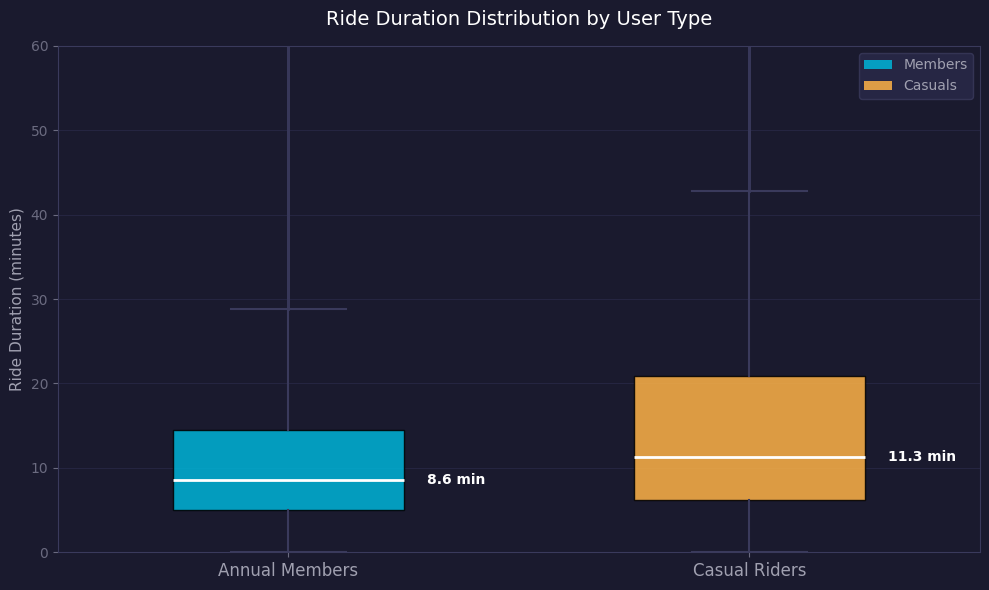

Chart saved


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
member_data = df[df['member_casual'] == 'member']['ride_length_min']
casual_data = df[df['member_casual'] == 'casual']['ride_length_min']

# Boxplot
bp = ax.boxplot(
    [member_data, casual_data],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#3a3a5c', linewidth=1.5),
    capprops=dict(color='#3a3a5c', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#3a3a5c', 
                    markersize=2, alpha=0.3, markeredgewidth=0)
)

# Apply colors
bp['boxes'][0].set_facecolor(COLOR_MEMBER)
bp['boxes'][0].set_alpha(0.85)
bp['boxes'][1].set_facecolor(COLOR_CASUAL)
bp['boxes'][1].set_alpha(0.85)

# Labels and formatting
ax.set_xticks([1, 2])
ax.set_xticklabels(['Annual Members', 'Casual Riders'], fontsize=12, color='#a0a0b0')
ax.set_ylabel('Ride Duration (minutes)', fontsize=11)
ax.set_title('Ride Duration Distribution by User Type', fontsize=14, pad=15)
ax.set_ylim(0, 60)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

# Annotations — median lines
medians = [member_data.median(), casual_data.median()]
for i, median in enumerate(medians):
    ax.text(i + 1.3, median, f'{median:.1f} min', 
            va='center', fontsize=10, color='white', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_MEMBER, alpha=0.85, label='Members'),
    Patch(facecolor=COLOR_CASUAL, alpha=0.85, label='Casuals')
]
ax.legend(handles=legend_elements, loc='upper right', 
          facecolor='#2a2a4a', edgecolor='#3a3a5c', 
          labelcolor='#a0a0b0', fontsize=10)

plt.tight_layout()
plt.savefig('01_ride_duration.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("Chart saved")

### Chart 1: Ride Duration Distribution by User Type

The boxplot reveals differences in each group of users in terms of trip duration.

Annual members show a compact, low-variance distribution, their rides 
concentrate tightly between 5 and 14 minutes, with a median of just 8.6 minutes. 
The small box size confirms what the statistics suggested: members are 
highly consistent and predictable in their ride duration, characteristic 
of a commuter profile with fixed, repetitive routes.


Casual riders, by contrast, display a significantly wider and taller box — 
their rides vary from roughly 7 to 20 minutes at the interquartile range, 
with a median of 11.3 minutes and an upper whisker reaching approximately 
42 minutes. This large box reflects high behavioral variability: casual riders 
include both short-trip users and extended leisure riders, confirming their 
diverse and unstructured usage patterns.

**The visual gap between the two boxes is the clearest possible representation 
of the core behavioral divide uncovered in this analysis: members ride short 
and consistently, casuals ride longer and unpredictably.**


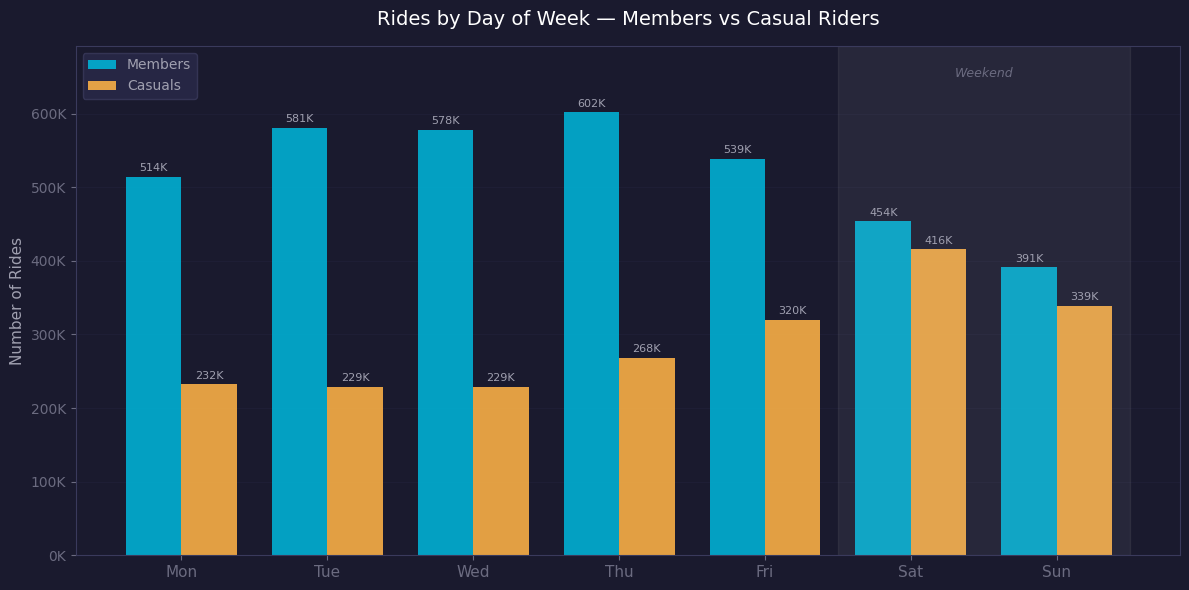

Chart saved


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

weekly = df.groupby(['member_casual', 'day_of_week']).size().reset_index(name='ride_count')
weekly['day_of_week'] = pd.Categorical(weekly['day_of_week'], categories=day_order, ordered=True)
weekly = weekly.sort_values('day_of_week')

member_data = weekly[weekly['member_casual'] == 'member']['ride_count'].values
casual_data = weekly[weekly['member_casual'] == 'casual']['ride_count'].values

# Bar positions
x = np.arange(len(day_order))
width = 0.38

# Plot bars
bars_m = ax.bar(x - width/2, member_data, width,
                color=COLOR_MEMBER, alpha=0.88, label='Members')
bars_c = ax.bar(x + width/2, casual_data, width,
                color=COLOR_CASUAL, alpha=0.88, label='Casuals')

# Labels on top of bars
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{bar.get_height()/1000:.0f}K',
            ha='center', va='bottom', fontsize=8, color='#a0a0b0')

for bar in bars_c:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{bar.get_height()/1000:.0f}K',
            ha='center', va='bottom', fontsize=8, color='#a0a0b0')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(day_labels, fontsize=11)
ax.set_ylabel('Number of Rides', fontsize=11)
ax.set_title('Rides by Day of Week — Members vs Casual Riders', fontsize=14, pad=15)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylim(0, max(member_data) * 1.15)

# Y axis in thousands
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Legend
ax.legend(facecolor='#2a2a4a', edgecolor='#3a3a5c',
          labelcolor='#a0a0b0', fontsize=10)

# Highlight weekend
ax.axvspan(4.5, 6.5, alpha=0.06, color='white', label='_nolegend_')
ax.text(5.5, max(member_data) * 1.08, 'Weekend', 
        ha='center', fontsize=9, color='#6b6b80', style='italic')

plt.tight_layout()
plt.savefig('02_weekly_patterns.png', dpi=150, 
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Chart saved")

### Chart 2: Rides by Day of Week — Members vs Casual Riders

The bar chart reveals a clear and opposing behavioral pattern between both user groups.

Annual members dominate weekday ridership, peaking on Thursday with 602K rides 
and declining consistently as the weekend approaches. Casual riders show the exact 
opposite — their usage grows steadily through the week, peaking on Saturday with 
416K rides. The shaded weekend area highlights precisely where this behavioral 
crossover occurs, the moment where leisure demand begins to rival commuter demand.

**Key takeaway: Members ride on a work schedule, casuals ride on a leisure schedule.**

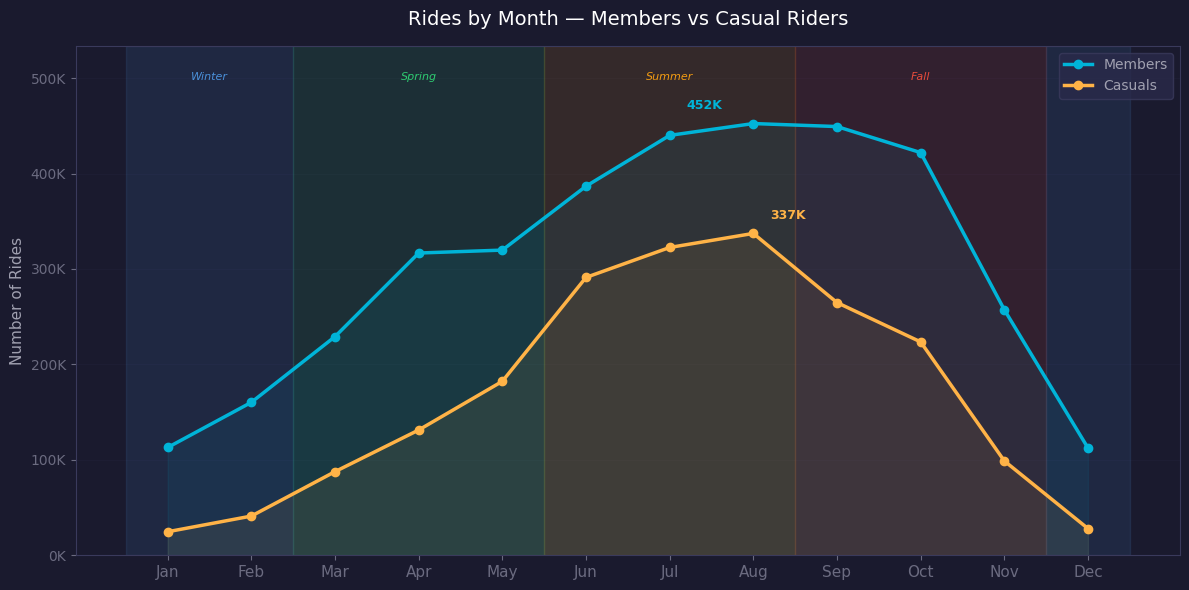

Chart saved


In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly = df.groupby(['member_casual', 'month']).size().reset_index(name='ride_count')
monthly['month'] = pd.Categorical(monthly['month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('month')

member_data = monthly[monthly['member_casual'] == 'member']['ride_count'].values
casual_data = monthly[monthly['member_casual'] == 'casual']['ride_count'].values

x = np.arange(len(month_order))

# Plot lines FIRST
ax.plot(x, member_data, color=COLOR_MEMBER, linewidth=2.5,
        marker='o', markersize=6, label='Members', zorder=3)
ax.plot(x, casual_data, color=COLOR_CASUAL, linewidth=2.5,
        marker='o', markersize=6, label='Casuals', zorder=3)

# Fill under lines
ax.fill_between(x, member_data, alpha=0.08, color=COLOR_MEMBER, zorder=2)
ax.fill_between(x, casual_data, alpha=0.08, color=COLOR_CASUAL, zorder=2)

# Season shading AFTER lines so they overlay
seasons = [
    (-0.5, 1.5, '#4a90d9', 'Winter'),
    (1.5, 4.5, '#2ecc71', 'Spring'),
    (4.5, 7.5, '#f39c12', 'Summer'),
    (7.5, 10.5, '#e74c3c', 'Fall'),
    (10.5, 11.5, '#4a90d9', ''),
]

for start, end, color, label in seasons:
    ax.axvspan(start, end, alpha=0.12, color=color, zorder=1)

# Season labels
ax.text(0.5, max(member_data) * 1.10, 'Winter', ha='center',
        fontsize=8, color='#4a90d9', style='italic')
ax.text(3, max(member_data) * 1.10, 'Spring', ha='center',
        fontsize=8, color='#2ecc71', style='italic')
ax.text(6, max(member_data) * 1.10, 'Summer', ha='center',
        fontsize=8, color='#f39c12', style='italic')
ax.text(9, max(member_data) * 1.10, 'Fall', ha='center',
        fontsize=8, color='#e74c3c', style='italic')

# Peak annotations
peak_m = np.argmax(member_data)
peak_c = np.argmax(casual_data)
ax.annotate(f'{member_data[peak_m]/1000:.0f}K',
            xy=(peak_m, member_data[peak_m]),
            xytext=(peak_m - 0.8, member_data[peak_m] + 15000),
            fontsize=9, color=COLOR_MEMBER, fontweight='bold')
ax.annotate(f'{casual_data[peak_c]/1000:.0f}K',
            xy=(peak_c, casual_data[peak_c]),
            xytext=(peak_c + 0.2, casual_data[peak_c] + 15000),
            fontsize=9, color=COLOR_CASUAL, fontweight='bold')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_ylabel('Number of Rides', fontsize=11)
ax.set_title('Rides by Month — Members vs Casual Riders', fontsize=14, pad=15)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, max(member_data) * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(facecolor='#2a2a4a', edgecolor='#3a3a5c',
          labelcolor='#a0a0b0', fontsize=10)

plt.tight_layout()
plt.savefig('03_monthly_patterns.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Chart saved")

### Chart 3: Rides by Month — Members vs Casual Riders

Both user groups show a strong seasonal correlation — ridership rises with warmer 
temperatures and falls sharply during cold months, confirming that climate 
cycle is a primary driver of Cyclistic's overall demand.

Spring marks the acceleration point for casual riders — from March to June, 
their ridership grows more than 3x (from 87K to 291K rides), signaling that 
early spring is a critical moment when casual riders are rekindling their habit 
and most open to engagement.

The key behavioral difference emerges in the transition from summer to fall: casual 
riders experience a significantly steeper decline starting in September, dropping to 
near-negligible levels by winter, while annual members maintain a much more resilient 
baseline throughout the colder months — reinforcing their commuter-driven, 
weather-independent usage pattern.

**Key insight: The optimal window for membership conversion campaigns is 
late spring through summer (May–August)** — when casual ridership is at its 
peak and users are most engaged with the platform. Waiting until late summer 
to launch campaigns risks missing riders at their highest motivation point. 
The strongest opportunity lies in reaching casual riders *before* peak season, 
so they can experience the full value of an annual membership throughout summer.**

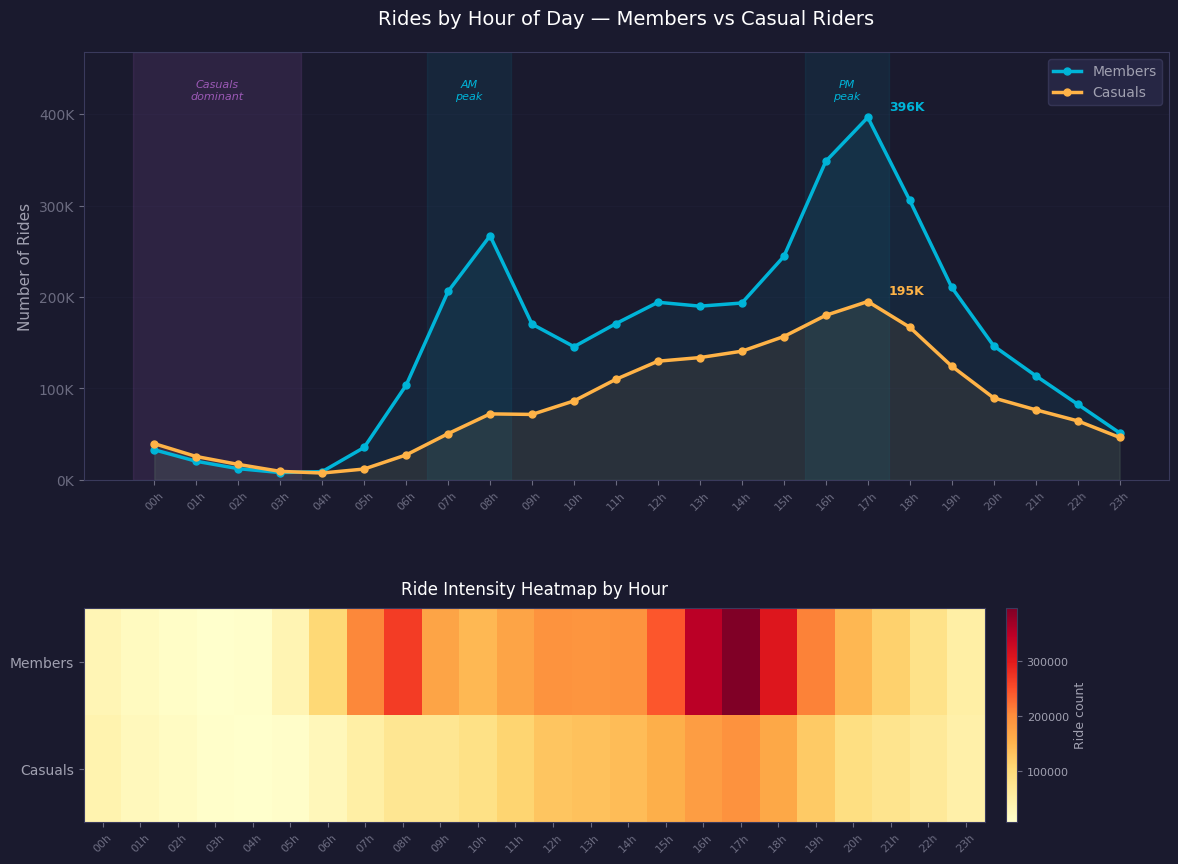

Chart saved


In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                                gridspec_kw={'height_ratios': [2, 1]})
fig.subplots_adjust(hspace=0.4)

# Prepare data
hourly = df.groupby(['member_casual', 'hour']).size().reset_index(name='ride_count')
member_h = hourly[hourly['member_casual'] == 'member']['ride_count'].values
casual_h = hourly[hourly['member_casual'] == 'casual']['ride_count'].values
hours = np.arange(24)

# ── CHART 1: Line chart ──────────────────────────────────────────
# Night zone highlight (midnight to 4am)
ax1.axvspan(-0.5, 3.5, alpha=0.15, color='#9b59b6', zorder=1)
ax1.text(1.5, max(member_h) * 1.05, 'Casuals\ndominant', ha='center',
         fontsize=8, color='#9b59b6', style='italic')

# Morning peak highlight
ax1.axvspan(6.5, 8.5, alpha=0.08, color=COLOR_MEMBER, zorder=1)
ax1.text(7.5, max(member_h) * 1.05, 'AM\npeak', ha='center',
         fontsize=8, color=COLOR_MEMBER, style='italic')

# Evening peak highlight  
ax1.axvspan(15.5, 17.5, alpha=0.08, color=COLOR_MEMBER, zorder=1)
ax1.text(16.5, max(member_h) * 1.05, 'PM\npeak', ha='center',
         fontsize=8, color=COLOR_MEMBER, style='italic')

# Lines
ax1.plot(hours, member_h, color=COLOR_MEMBER, linewidth=2.5,
         marker='o', markersize=5, label='Members', zorder=3)
ax1.plot(hours, casual_h, color=COLOR_CASUAL, linewidth=2.5,
         marker='o', markersize=5, label='Casuals', zorder=3)

# Fill under lines
ax1.fill_between(hours, member_h, alpha=0.08, color=COLOR_MEMBER, zorder=2)
ax1.fill_between(hours, casual_h, alpha=0.08, color=COLOR_CASUAL, zorder=2)

# Peak annotations
ax1.annotate(f"{max(member_h)/1000:.0f}K",
             xy=(hours[np.argmax(member_h)], max(member_h)),
             xytext=(hours[np.argmax(member_h)] + 0.5, max(member_h) + 8000),
             fontsize=9, color=COLOR_MEMBER, fontweight='bold')
ax1.annotate(f"{max(casual_h)/1000:.0f}K",
             xy=(hours[np.argmax(casual_h)], max(casual_h)),
             xytext=(hours[np.argmax(casual_h)] + 0.5, max(casual_h) + 8000),
             fontsize=9, color=COLOR_CASUAL, fontweight='bold')

ax1.set_xticks(hours)
ax1.set_xticklabels([f'{h:02d}h' for h in hours], fontsize=8, rotation=45)
ax1.set_ylabel('Number of Rides', fontsize=11)
ax1.set_title('Rides by Hour of Day — Members vs Casual Riders', fontsize=14, pad=20)
ax1.yaxis.grid(True, alpha=0.3)
ax1.set_axisbelow(True)
ax1.set_ylim(0, max(member_h) * 1.18)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.legend(facecolor='#2a2a4a', edgecolor='#3a3a5c',
           labelcolor='#a0a0b0', fontsize=10)

# ── CHART 2: Heatmap ─────────────────────────────────────────────
heatmap_data = np.array([member_h, casual_h])
im = ax2.imshow(heatmap_data, aspect='auto', cmap='YlOrRd',
                interpolation='nearest')

ax2.set_xticks(hours)
ax2.set_xticklabels([f'{h:02d}h' for h in hours], fontsize=8, rotation=45)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Members', 'Casuals'], fontsize=10, color='#a0a0b0')
ax2.set_title('Ride Intensity Heatmap by Hour', fontsize=12, pad=10)

# Colorbar
cbar = plt.colorbar(im, ax=ax2, orientation='vertical', pad=0.02)
cbar.ax.yaxis.set_tick_params(color='#6b6b80')
cbar.ax.set_ylabel('Ride count', fontsize=9, color='#a0a0b0')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#a0a0b0', fontsize=8)

plt.savefig('04_hourly_patterns.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Chart saved")

### Chart 4: Rides by Hour of Day — Members vs Casual Riders

Annual members follow a clear commuter pattern — a morning spike at 8AM 
and a stronger evening peak at 5PM (396K rides), both aligned with typical 
work start and end times. Casual riders show a single smooth arc, growing 
steadily through the day and peaking around 5PM (195K rides) with no 
morning spike — riding freely, not on a schedule.

The heatmap reinforces this visually: members show two intense zones at 
7-8AM and 4-5PM, while casuals concentrate their activity in the 
afternoon hours only.

**One standout finding:** between 12AM and 3:59AM, casual riders 
outnumber members — the only window in the day where this happens. 
This late-night segment represents an untapped conversion opportunity 
that current membership campaigns are not reaching.

**Key insight: Members ride on a schedule, casuals ride on a whim — 
and the late-night hours reveal a hidden casual segment worth targeting.**

## 6. Act — Top 3 Recommendations <a name="6-act"></a>

Based on the analysis, three data-driven recommendations are proposed to 
convert casual riders into annual members.

---

### Recommendation 1: Launch membership campaigns in spring 
Casual ridership grows more than 3x between March and June. Launching 
campaigns in **April–May** lets casual riders experience the full value 
of a membership before peak season begins.

*Strike before the peak, not during it.*

---

### Recommendation 2: Target weekends with leisure-focused messaging 
Casual riders peak on Saturdays. Commuter-focused messaging won't resonate 
with them — campaigns should highlight **unlimited rides for weekend outings** 
and show that a membership pays for itself in just a few weekend trips.

*Speak to how they actually ride, not how members ride.*

---

### Recommendation 3: Reach the late-night segment 
Between 12AM and 4AM, casuals outnumber members — an untapped segment. 
**Late-night perks or incentives** could unlock conversions that no 
current campaign is targeting.

*The night shift is an untapped market.*

---

### Summary

| Recommendation | Target | Timing |
|---|---|---|
| Seasonal spring campaigns | All casual riders | April — May |
| Weekend leisure messaging | Weekend casual riders | Saturday peak |
| Late-night rider incentives | Nightlife casual riders | 12AM — 4AM |